/home/emastr/github/aipek_task_2026/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Creating PersistentDataset...
BasicUNet features: (32, 32, 64, 128, 256, 32).
Time taken for forward pass: 0.7086 seconds


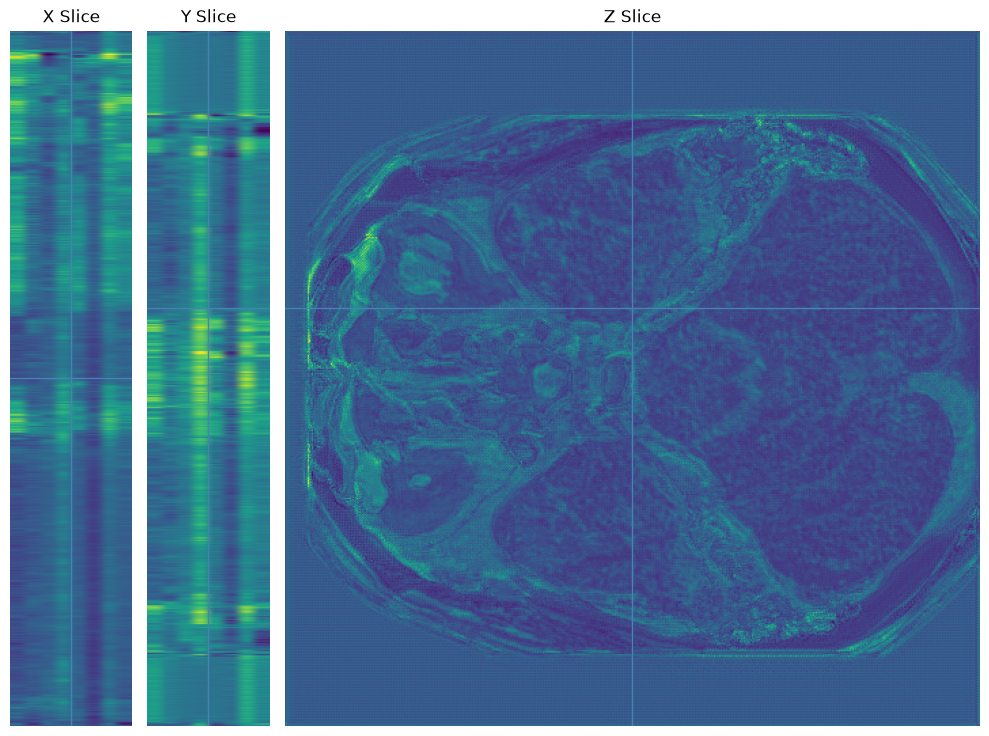

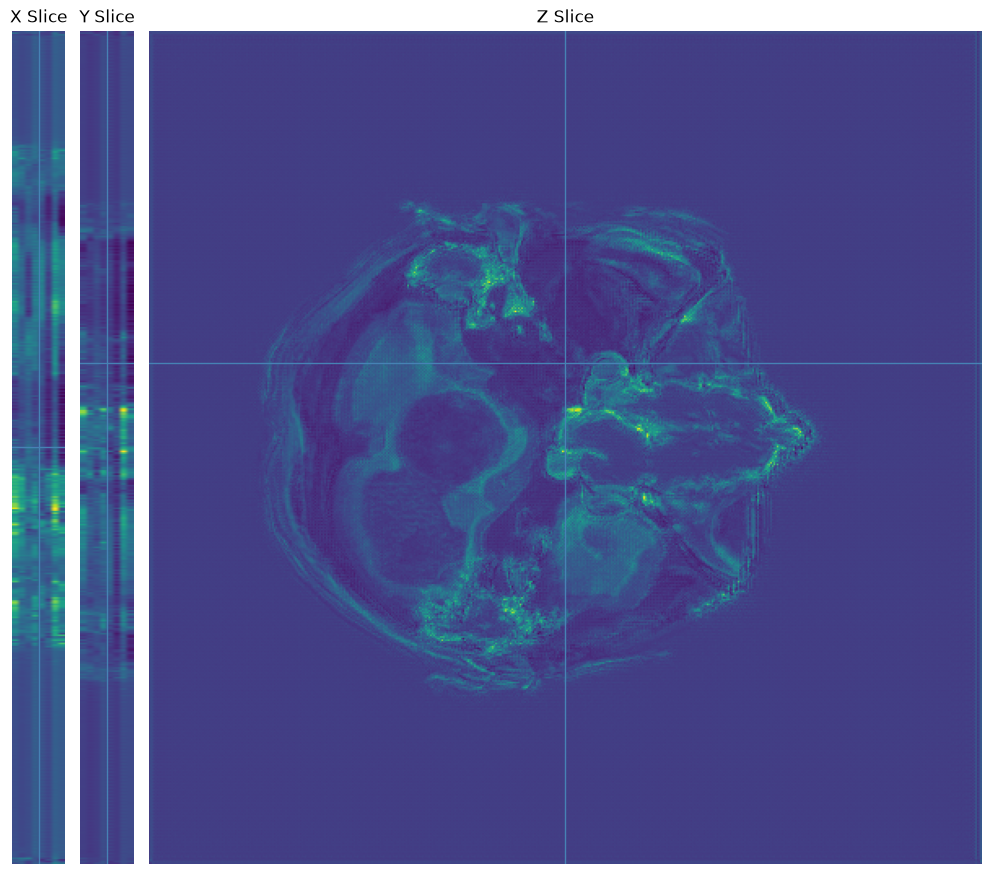

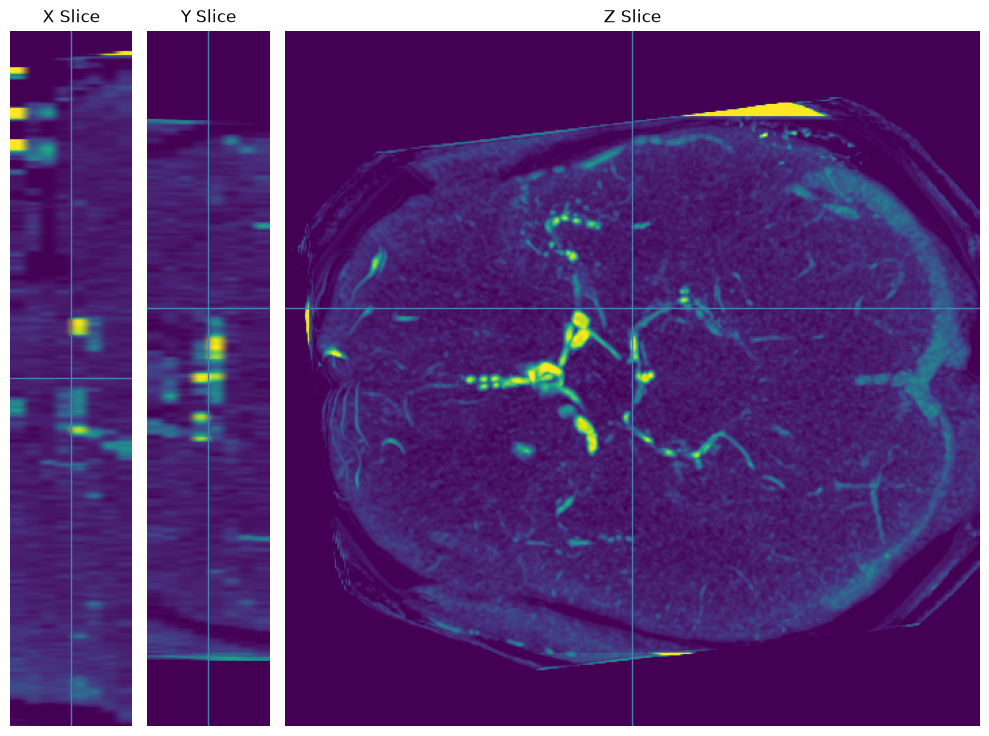

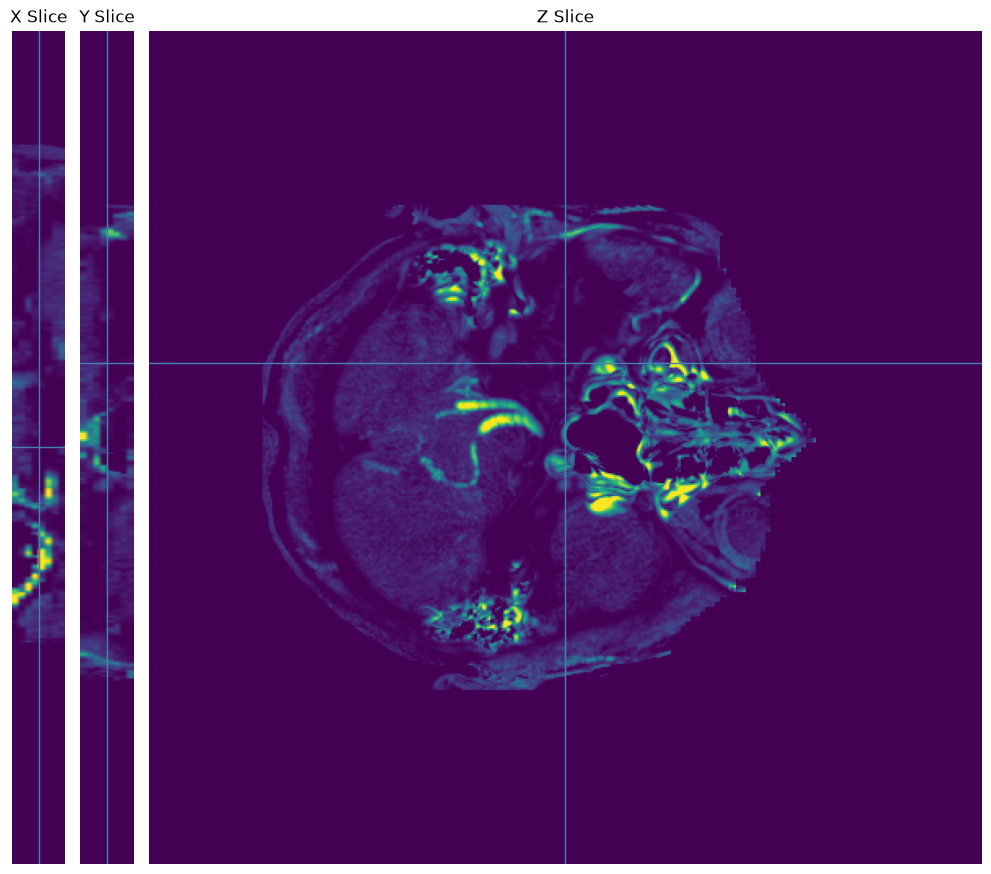

In [ ]:
import torch
import torch.nn as nn

import sys
sys.path.append('../')


torch.manual_seed(0)

from data import CONSTANTS
from monai.networks.nets import BasicUNet
from data_monai import create_data_loader, plot_slices

class eDiff(nn.Module):
    
    def __init__(self, base, mid, refiner):
        super().__init__()
        self.base = base
        self.mid = mid
        self.refiner = refiner
        self.dt = 0.
        
    def forward(self, x):
        x = x + self.base(x)
        x = x + self.mid(x) * self.dt
        x = x + self.refiner(x) * self.dt
        return x
    
    

channels = 8 # Number of slices per chunk
train_loader = create_data_loader(
    image_dir = f"../{CONSTANTS.NORM_DATA_PATH_TRAIN_INP}",
    label_dir = f"../{CONSTANTS.NORM_DATA_PATH_TRAIN_OUT}",
    channels = channels, # Number of slices per chunk
    batch_size = 16, # Number of chunks per GPU batch
    device = "cuda"
)

data = next(iter(train_loader))
x = data["input"].squeeze().to("cuda", dtype=torch.float32, non_blocking=True)
y = data["output"].squeeze().to("cuda", dtype=torch.float32, non_blocking=True)
pixdim = data["pixdim"].squeeze()


net = BasicUNet(
    spatial_dims=2,
    in_channels= channels,      # Yt, X and t.
    out_channels= channels,             # Y0 - Y1
    features=(32, 32, 64, 128, 256, 32),
).to("cuda", dtype=torch.float32)


timesteps = torch.ones(1).to("cuda", dtype=torch.float32)

import time
#with torch.no_grad():
t = time.time()
ynet = net(x)
ynet_norm = torch.norm(ynet -  y)**2
ynet_norm.backward()
ynet = ynet.detach()
t = time.time() - t
print(f"Time taken for forward pass: {t:.4f} seconds")
plot_slices(ynet[:2], pixdim[:2], (0.4, 0.5, 0.6), (10, 10, 10))
plot_slices(y[:2], pixdim[:2], (0.4, 0.5, 0.6), (10, 10, 10))


# clear cache
torch.cuda.empty_cache()